In [1]:
import warnings
warnings.filterwarnings("ignore")
from pandas import read_csv
from pandas import to_datetime
from pandas import Timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as Ticker
from datetime import date
from yfinance import download
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [2]:
cnpj = "89.637.490/0001-45"
ticker = "klbn4.sa"

# **FUNÇÕES**

In [3]:
def read_itr_DRE_con(df, cnpj, ds_conta=None, cd_conta=None, view_ds_conta_e_cd_conta=False):

    # selecionando dados de uma empresa especifica
    df= df[df["CNPJ_CIA"] == cnpj]

    # selecionando informação atualizada
    df = df[df["ORDEM_EXERC"] == "ÚLTIMO"]

    if view_ds_conta_e_cd_conta:
        df_unique = df[['CD_CONTA', 'DS_CONTA']]
        df_unique = df_unique.drop_duplicates(subset=['CD_CONTA'])
        for _cd_conta, _ds_conta in df_unique.values:
            profundidade = _cd_conta.count('.')   # nível hierárquico
            indentacao = '    ' * profundidade   # 4 espaços por nível
            print(f"{indentacao}{_cd_conta} {_ds_conta}")

    # escolhendo informação 
    if ds_conta != None:
        df = df[df["DS_CONTA"] == ds_conta]

    if cd_conta != None:
        df = df[df["CD_CONTA"] == cd_conta]

    # criando intervalo das informações
    df = df[['DENOM_CIA', 'DS_CONTA', 'CD_CONTA', 'DT_REFER', 'DT_INI_EXERC', 'VL_CONTA']]
    df['DT_REFER'] = to_datetime(df['DT_REFER'])
    df['DT_INI_EXERC'] = to_datetime(df['DT_INI_EXERC'])
    df['intervalo'] = df['DT_REFER'] - df['DT_INI_EXERC']

    # selecionando intervalo trimestral
    df = df[df['intervalo'] < Timedelta(days=95)]
    
    return df

In [4]:
def cascata(df_unique):
    for _cd_conta, _ds_conta in df_unique.values:
        profundidade = _cd_conta.count('.')   # nível hierárquico
        indentacao = '    ' * profundidade   # 4 espaços por nível
        print(f"{indentacao}{_cd_conta} {_ds_conta}")

In [5]:
def get_info_trimestral(df):
    df = df[['DENOM_CIA', 'DS_CONTA', 'CD_CONTA', 'DT_REFER', 'DT_INI_EXERC', 'VL_CONTA']]
    df['DT_REFER'] = to_datetime(df['DT_REFER'])
    df['DT_INI_EXERC'] = to_datetime(df['DT_INI_EXERC'])
    df['INTERVALO'] = df['DT_REFER'] - df['DT_INI_EXERC']

    # selecionando intervalo trimestral
    df = df[df['INTERVALO'] < Timedelta(days=95)]
    return df

---

# **BPA**

*BPA Consolidado (Balanço Patrimonial Ativo)*

**con**

In [6]:
# leitura do arquivo
file = "BPA_con"
file = f"itr_cia_aberta_{file}_2011-2025.csv"
path = f"Q:\\financial_data_pipelines\\data\pipelines\\cvm_formulario_informacoes_trimestrais\\interim\\{file}"

df_bpa_con = read_csv(path, encoding="utf-8")

In [7]:
df_bpa_con.head(2)

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
0,00.001.180/0001-26,2011-03-31,1,CENTRAIS ELET BRAS S.A. - ELETROBRAS,2437,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,PENÚLTIMO,2010-12-31,1,Ativo Total,146901002.0,S
1,00.001.180/0001-26,2011-03-31,1,CENTRAIS ELET BRAS S.A. - ELETROBRAS,2437,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2011-03-31,1,Ativo Total,149751700.0,S


In [8]:
df_bpa_con.tail(2)

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
2172349,97.837.181/0001-47,2025-09-30,1,DEXCO S.A.,21091,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2025-09-30,1.02.04.02.12,Goodwill na aquisição da Castelatto 2022,46670.0,N
2172350,97.837.181/0001-47,2025-09-30,1,DEXCO S.A.,21091,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2025-09-30,1.02.04.02.13,Goodwill na aquisição da Guarani Florestal 2025,24460.0,N


In [9]:
# selecionando dados de uma empresa especifica
df_bpa_con= df_bpa_con[df_bpa_con["CNPJ_CIA"] == cnpj]

# selecionando informação atualizada
df_bpa_con = df_bpa_con[df_bpa_con["ORDEM_EXERC"] == "ÚLTIMO"]

In [10]:
df_bpa_con_unique = df_bpa_con[['CD_CONTA', 'DS_CONTA']].drop_duplicates(subset=['CD_CONTA'])
cascata(df_bpa_con_unique)

1 Ativo Total
    1.01 Ativo Circulante
        1.01.01 Caixa e Equivalentes de Caixa
        1.01.02 Aplicações Financeiras
            1.01.02.01 Aplicações Financeiras Avaliadas a Valor Justo
                1.01.02.01.01 Títulos para Negociação
                1.01.02.01.02 Títulos Disponíveis para Venda
            1.01.02.02 Aplicações Financeiras Avaliadas ao Custo Amortizado
                1.01.02.02.01 Títulos Mantidos até o Vencimento
        1.01.03 Contas a Receber
            1.01.03.01 Clientes
                1.01.03.01.01 Contas a Receber de Clientes
                1.01.03.01.02 Provisão para Créditos de Liquidação Duvidosa
            1.01.03.02 Outras Contas a Receber
        1.01.04 Estoques
        1.01.05 Ativos Biológicos
        1.01.06 Tributos a Recuperar
            1.01.06.01 Tributos Correntes a Recuperar
        1.01.07 Despesas Antecipadas
            1.01.07.01 Despesas Antecipadas - Terceiros
            1.01.07.02 Despesas Antecipadas - Partes Relacio

In [11]:
# inicio da cascata
codigos = df_bpa_con_unique[df_bpa_con_unique['CD_CONTA'].apply(lambda x: x.count('.')) == 1]
codigos

,CD_CONTA,DS_CONTA
128151,1.01,Ativo Circulante
128199,1.02,Ativo Não Circulante


In [12]:
df_bpa_con.head(2)

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
128149,89.637.490/0001-45,2011-03-31,2,KLABIN S.A.,12653,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2011-03-31,1,Ativo Total,12220915.0,S
128151,89.637.490/0001-45,2011-03-31,2,KLABIN S.A.,12653,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2011-03-31,1.01,Ativo Circulante,4015790.0,S


## **ATIVO CIRCULANTE**

*Ativo circulante é o conjunto de bens e direitos de uma empresa que serão convertidos em dinheiro, vendidos ou consumidos até o fim do próximo exercício social (normalmente dentro de 12 meses).*

In [13]:
# selecionando ativo circulante
df_ativo_circulante = df_bpa_con[df_bpa_con["CD_CONTA"] == '1.01']
df_ativo_circulante.tail(3)

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
2165745,89.637.490/0001-45,2025-03-31,1,KLABIN S.A.,12653,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2025-03-31,1.01,Ativo Circulante,12994752.0,S
2165879,89.637.490/0001-45,2025-06-30,1,KLABIN S.A.,12653,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2025-06-30,1.01,Ativo Circulante,15144906.0,S
2166013,89.637.490/0001-45,2025-09-30,1,KLABIN S.A.,12653,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2025-09-30,1.01,Ativo Circulante,16586925.0,S


In [14]:
# ajustando datas e criando colunas com mes e ano
df_ativo_circulante['DT_REFER'] = to_datetime(df_ativo_circulante['DT_REFER'])
df_ativo_circulante['DT_REFER_ano'] = df_ativo_circulante['DT_REFER'].dt.year
df_ativo_circulante['DT_REFER_mes'] = df_ativo_circulante['DT_REFER'].dt.month
df_ativo_circulante.tail(2)

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA,DT_REFER_ano,DT_REFER_mes
2165879,89.637.490/0001-45,2025-06-30,1,KLABIN S.A.,12653,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2025-06-30,1.01,Ativo Circulante,15144906.0,S,2025,6
2166013,89.637.490/0001-45,2025-09-30,1,KLABIN S.A.,12653,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2025-09-30,1.01,Ativo Circulante,16586925.0,S,2025,9


In [15]:
# download serie de preços
df_price_ativo_circulante = download(
    ticker, 
    start=df_ativo_circulante['DT_REFER'].iloc[0], 
    end=date.today(), 
    auto_adjust=False).droplevel(1, axis=1)

[*********************100%***********************]  1 of 1 completed


In [16]:
df_price_ativo_circulante = df_price_ativo_circulante.reset_index()
df_price_ativo_circulante['Date'] = to_datetime(df_price_ativo_circulante['Date'])
df_price_ativo_circulante['Date_ano'] = df_price_ativo_circulante['Date'].dt.year
df_price_ativo_circulante['Date_mes'] = df_price_ativo_circulante['Date'].dt.month
df_price_ativo_circulante

Price,Date,Adj Close,Close,High,Low,Open,Volume,Date_ano,Date_mes
0,2011-03-31,0.617848,1.188118,1.188118,1.144914,1.153915,21345087,2011,3
1,2011-04-01,0.617848,1.188118,1.188118,1.188118,1.188118,0,2011,4
2,2011-04-04,0.636571,1.224122,1.242124,1.207920,1.229522,8969103,2011,4
3,2011-04-05,0.636571,1.224122,1.224122,1.224122,1.224122,0,2011,4
4,2011-04-06,0.615040,1.182718,1.225922,1.182718,1.220522,7193725,2011,4
...,...,...,...,...,...,...,...,...,...
3665,2025-12-29,3.740000,3.740000,3.760000,3.720000,3.730000,1618900,2025,12
3666,2025-12-30,3.760000,3.760000,3.780000,3.700000,3.760000,1783000,2025,12
3667,2026-01-02,3.810000,3.810000,3.810000,3.750000,3.760000,2003700,2026,1
3668,2026-01-05,3.710000,3.710000,3.810000,3.710000,3.800000,3410400,2026,1


In [17]:
# ajustando VL_CONTA com o preço do ativo
lista_fund_ajust_data = []
for date_ano, date_mes in df_price_ativo_circulante[['Date_ano', 'Date_mes']].values:
    info = df_ativo_circulante.loc[(df_ativo_circulante['DT_REFER_ano'] == date_ano) & (df_ativo_circulante['DT_REFER_mes'] == date_mes)]['VL_CONTA']
    try:
        last = info.iloc[0]
        lista_fund_ajust_data.append(last)
    except:
        lista_fund_ajust_data.append(last)

In [18]:
df_price_ativo_circulante['Ativo Circulante'] = lista_fund_ajust_data

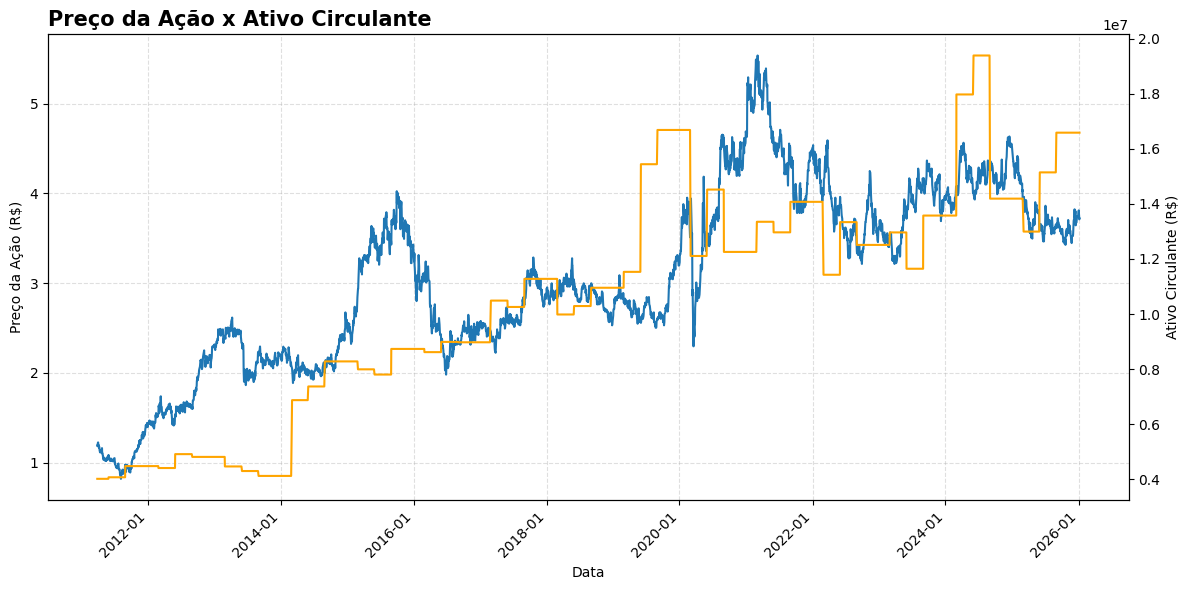

In [19]:
# Cria apenas 1 subplot
fig, ax1 = plt.subplots(
    figsize=(12, 6)
)

# ===== BLOCO ÚNICO =====
# Eixo Y primário (Preço)
ax1.plot(df_price_ativo_circulante["Date"], df_price_ativo_circulante["Close"], label="Preço (Close)")
ax1.set_ylabel("Preço da Ação (R$)")
ax1.tick_params(axis="y")

# Eixo Y secundário (Ativo Circulante)
ax2 = ax1.twinx()
ax2.plot(
    df_price_ativo_circulante["Date"],
    df_price_ativo_circulante["Ativo Circulante"],
    label="Ativo Circulante",
    color="orange"
)
ax2.set_ylabel("Ativo Circulante (R$)")
ax2.tick_params(axis="y")

ax1.set_title("Preço da Ação x Ativo Circulante", fontsize=15, fontweight='bold', loc='left')
ax1.set_xlabel("Data")

# ===== FORMATAÇÃO DE DATAS =====
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# ===== GRADE =====
ax1.grid(True, linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()


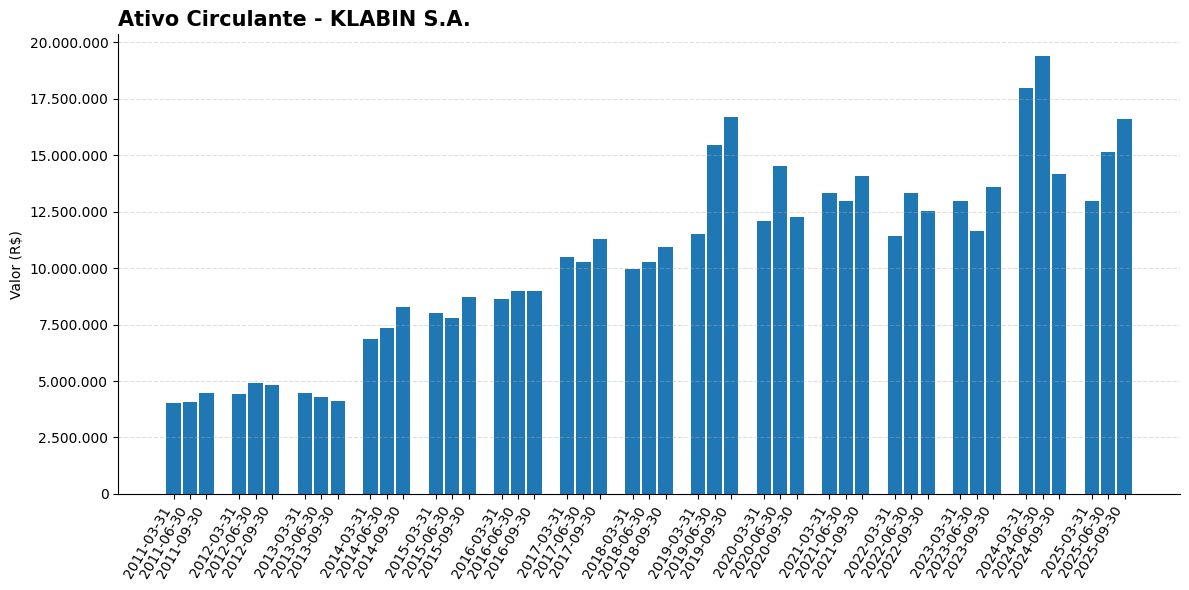

In [20]:
# Figura
plt.figure(figsize=(12, 6))

# Gráfico de barras
plt.bar(df_ativo_circulante['DT_REFER'], df_ativo_circulante['VL_CONTA'], width=80)
plt.title(f"{df_ativo_circulante['DS_CONTA'].iloc[0]} - {df_ativo_circulante['DENOM_CIA'].iloc[0]}", fontsize=15, fontweight='bold', loc='left')
plt.ylabel('Valor (R$)')
plt.xlabel('')

# Formatação do eixo Y
plt.gca().yaxis.set_major_formatter(Ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))

# Eixo X
plt.xticks(rotation=60, ha='right')

plt.xticks(df_ativo_circulante['DT_REFER'], df_ativo_circulante['DT_REFER'].dt.strftime('%Y-%m-%d'), rotation=60, ha='right')

# Grid leve (horizontal apenas)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.grid(axis='x', visible=False)

# Remove bordas superiores e laterais
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Margens
plt.tight_layout()

plt.show()


---

## **ATIVO NÃO CIRCULANTE**

*Ativo não circulante é o conjunto de bens e direitos da empresa que não serão convertidos em caixa no curto prazo (mais de 12 meses).*

In [21]:
codigos

,CD_CONTA,DS_CONTA
128151,1.01,Ativo Circulante
128199,1.02,Ativo Não Circulante


In [22]:
# selecionando ativo nao circulante
df_ativo_nao_circulante = df_bpa_con[df_bpa_con["CD_CONTA"] == '1.02']
df_ativo_nao_circulante.tail(3)

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
2165791,89.637.490/0001-45,2025-03-31,1,KLABIN S.A.,12653,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2025-03-31,1.02,Ativo Não Circulante,44478412.0,S
2165929,89.637.490/0001-45,2025-06-30,1,KLABIN S.A.,12653,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2025-06-30,1.02,Ativo Não Circulante,45190337.0,S
2166038,89.637.490/0001-45,2025-09-30,1,KLABIN S.A.,12653,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2025-09-30,1.02,Ativo Não Circulante,45576754.0,S


In [23]:
# ajustando datas e criando colunas com mes e ano
df_ativo_nao_circulante['DT_REFER'] = to_datetime(df_ativo_nao_circulante['DT_REFER'])
df_ativo_nao_circulante['DT_REFER_ano'] = df_ativo_nao_circulante['DT_REFER'].dt.year
df_ativo_nao_circulante['DT_REFER_mes'] = df_ativo_nao_circulante['DT_REFER'].dt.month
df_ativo_nao_circulante.tail(2)

,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA,DT_REFER_ano,DT_REFER_mes
2165929,89.637.490/0001-45,2025-06-30,1,KLABIN S.A.,12653,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2025-06-30,1.02,Ativo Não Circulante,45190337.0,S,2025,6
2166038,89.637.490/0001-45,2025-09-30,1,KLABIN S.A.,12653,DF Consolidado - Balanço Patrimonial Ativo,REAL,MIL,ÚLTIMO,2025-09-30,1.02,Ativo Não Circulante,45576754.0,S,2025,9


In [24]:
# download serie de preços
df_price_ativo_nao_circulante = download(
    ticker, 
    start=df_ativo_circulante['DT_REFER'].iloc[0], 
    end=date.today(), 
    auto_adjust=False).droplevel(1, axis=1)

[*********************100%***********************]  1 of 1 completed


In [25]:
df_price_ativo_nao_circulante = df_price_ativo_nao_circulante.reset_index()
df_price_ativo_nao_circulante['Date'] = to_datetime(df_price_ativo_nao_circulante['Date'])
df_price_ativo_nao_circulante['Date_ano'] = df_price_ativo_nao_circulante['Date'].dt.year
df_price_ativo_nao_circulante['Date_mes'] = df_price_ativo_nao_circulante['Date'].dt.month
df_price_ativo_nao_circulante

Price,Date,Adj Close,Close,High,Low,Open,Volume,Date_ano,Date_mes
0,2011-03-31,0.617848,1.188118,1.188118,1.144914,1.153915,21345087,2011,3
1,2011-04-01,0.617848,1.188118,1.188118,1.188118,1.188118,0,2011,4
2,2011-04-04,0.636571,1.224122,1.242124,1.207920,1.229522,8969103,2011,4
3,2011-04-05,0.636571,1.224122,1.224122,1.224122,1.224122,0,2011,4
4,2011-04-06,0.615040,1.182718,1.225922,1.182718,1.220522,7193725,2011,4
...,...,...,...,...,...,...,...,...,...
3665,2025-12-29,3.740000,3.740000,3.760000,3.720000,3.730000,1618900,2025,12
3666,2025-12-30,3.760000,3.760000,3.780000,3.700000,3.760000,1783000,2025,12
3667,2026-01-02,3.810000,3.810000,3.810000,3.750000,3.760000,2003700,2026,1
3668,2026-01-05,3.710000,3.710000,3.810000,3.710000,3.800000,3410400,2026,1


In [26]:
# ajustando VL_CONTA com o preço do ativo
lista_fund_ajust_data = []
for date_ano, date_mes in df_price_ativo_nao_circulante[['Date_ano', 'Date_mes']].values:
    info = df_ativo_nao_circulante.loc[(df_ativo_nao_circulante['DT_REFER_ano'] == date_ano) & (df_ativo_nao_circulante['DT_REFER_mes'] == date_mes)]['VL_CONTA']
    try:
        last = info.iloc[0]
        lista_fund_ajust_data.append(last)
    except:
        lista_fund_ajust_data.append(last)

In [27]:
df_price_ativo_nao_circulante['Ativo Circulante'] = lista_fund_ajust_data

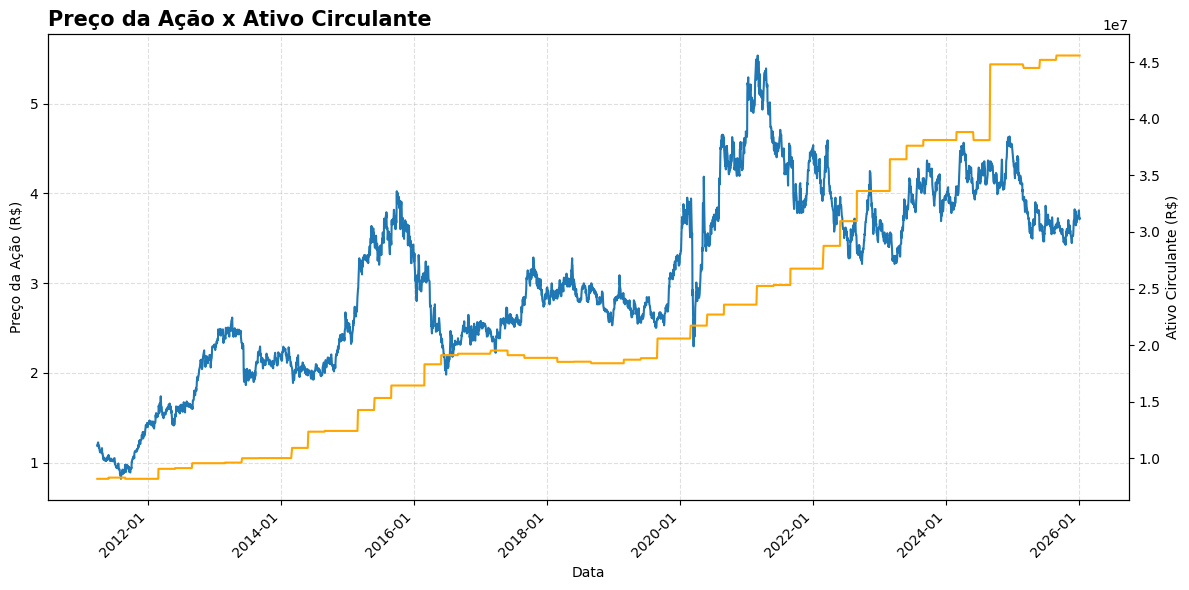

In [28]:
# Cria apenas 1 subplot
fig, ax1 = plt.subplots(
    figsize=(12, 6)
)

# ===== BLOCO ÚNICO =====
# Eixo Y primário (Preço)
ax1.plot(df_price_ativo_nao_circulante["Date"], df_price_ativo_nao_circulante["Close"], label="Preço (Close)")
ax1.set_ylabel("Preço da Ação (R$)")
ax1.tick_params(axis="y")

# Eixo Y secundário (Ativo Circulante)
ax2 = ax1.twinx()
ax2.plot(
    df_price_ativo_nao_circulante["Date"],
    df_price_ativo_nao_circulante["Ativo Circulante"],
    label="Ativo Circulante",
    color="orange"
)
ax2.set_ylabel("Ativo Circulante (R$)")
ax2.tick_params(axis="y")

ax1.set_title("Preço da Ação x Ativo Circulante", fontsize=15, fontweight='bold', loc='left')
ax1.set_xlabel("Data")

# ===== FORMATAÇÃO DE DATAS =====
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# ===== GRADE =====
ax1.grid(True, linestyle="--", alpha=0.4)

fig.tight_layout()
plt.show()


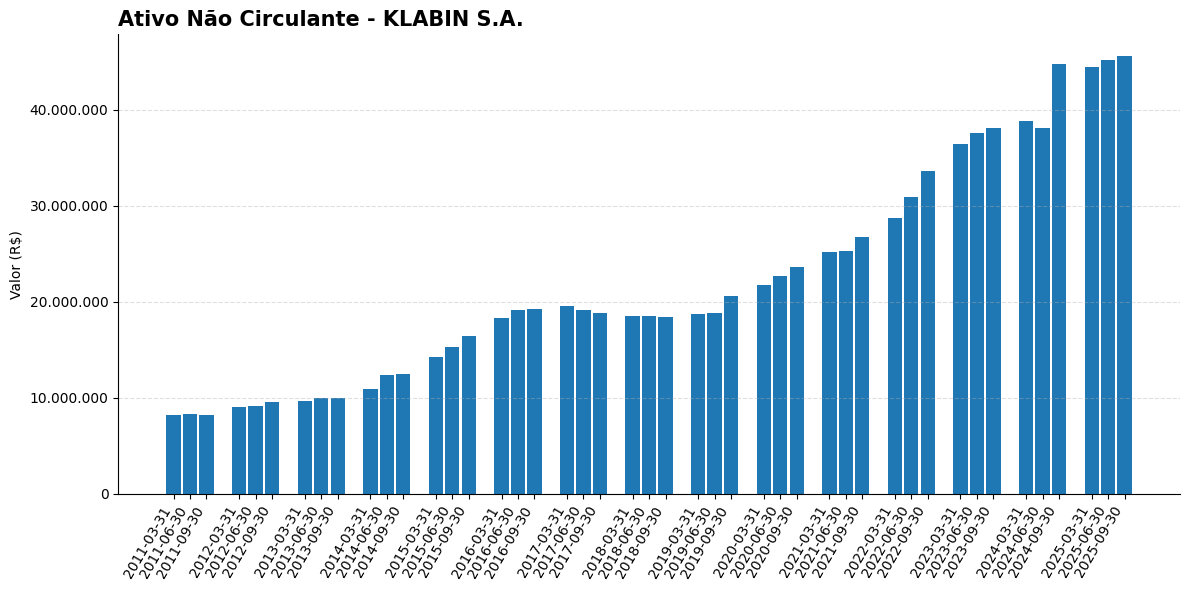

In [29]:
# Figura
plt.figure(figsize=(12, 6))

# Gráfico de barras
plt.bar(df_ativo_nao_circulante['DT_REFER'], df_ativo_nao_circulante['VL_CONTA'], width=80)
plt.title(f"{df_ativo_nao_circulante['DS_CONTA'].iloc[0]} - {df_ativo_nao_circulante['DENOM_CIA'].iloc[0]}", fontsize=15, fontweight='bold', loc='left')
plt.ylabel('Valor (R$)')
plt.xlabel('')

# Formatação do eixo Y
plt.gca().yaxis.set_major_formatter(Ticker.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))

# Eixo X
plt.xticks(rotation=60, ha='right')

plt.xticks(df_ativo_nao_circulante['DT_REFER'], df_ativo_nao_circulante['DT_REFER'].dt.strftime('%Y-%m-%d'), rotation=60, ha='right')

# Grid leve (horizontal apenas)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.grid(axis='x', visible=False)

# Remove bordas superiores e laterais
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Margens
plt.tight_layout()

plt.show()


---

# **BPP**

**con**